<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/08_pitfalls_and_leakage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- nav-header -->
[⬅ Previous](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/07_explainable_ai.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 08 of the course** · [Next: 09 — Optimizing your model ➡](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/09_model_optimization.ipynb)


# 🩺 Notebook 08 — How to fool yourself (and how not to)

> "The first principle is that you must not fool yourself — and you are the easiest person to fool." — Richard Feynman
>
> In medicine, a model that *looks* brilliant in a paper but *fails* at the bedside can cost lives.
> Almost every one of those failures traces back to a handful of avoidable mistakes made **while
> evaluating the model**. This notebook shows you each mistake with a **BEFORE** (inflated,
> too-good-to-be-true) number and an **AFTER** (honest) number, so you can recognise — and avoid —
> them in your own work and when reviewing others'.

**What you'll learn**
- Why a *random* train/test split on time-series data leaks — and how to split **by patient**.
- Why you must fit scalers and imputers **inside** the training fold, never on the whole dataset.
- How a single **target-leaking feature** turns a hard problem into a fake AUC of ≈1.0.
- Why **tuning on the test set** quietly inflates your reported performance.
- Why **accuracy lies** under class imbalance, and what **temporal / external validation** really tests.

**⏱️ Time:** ≈55 min · **Prerequisites:** Notebooks 05 (first models) & 06 (evaluation)


### ⚙️ Run me first
Run the setup cell below once. It installs anything missing, sets a clean plotting style, and defines the data loaders. (Same cell as every other notebook — no need to re-read it.)

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )


### 📦 The patient table
Notebook 04 built a one-row-per-stay table from the time-series. We include the canonical builder so this notebook is self-contained, then load both files: the **patient-level** table (`patients`) and the **raw time-series** (`ts`).

In [2]:
def build_patient_table(ts):
    """Aggregate the 4-hourly time-series into ONE row per ICU stay.
       (This is exactly what Notebook 04 teaches you to build.)"""
    df = ts.copy()
    # clean temperature: prefer Celsius; repair obvious Fahrenheit-entry errors; drop impossible
    tf = df["Temp_F"].where((df["Temp_F"] >= 90) & (df["Temp_F"] <= 110))
    tc = df["Temp_C"].where((df["Temp_C"] >= 25) & (df["Temp_C"] <= 45))
    df["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)
    # impossible vitals -> NaN, then forward/back-fill WITHIN each stay
    for c, lo, hi in [("HR",20,300),("SysBP",40,300),("MeanBP",20,220),("RR",3,80),("SpO2",30,100)]:
        df[c] = df[c].where((df[c] >= lo) & (df[c] <= hi))
    g = df.groupby("icustayid", group_keys=False)
    vit = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean"]
    df[vit] = g[vit].apply(lambda x: x.ffill().bfill())
    # winsorise skewed labs so one stray value can't define a min/max
    for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","INR","Glucose"]:
        lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
        df[c] = df[c].clip(lo, hi)
    tv = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean","GCS","Creatinine","BUN",
          "Arterial_lactate","WBC_count","Platelets_count","Potassium","Sodium",
          "Albumin","INR","Arterial_pH","Shock_Index","SOFA","SIRS","PaO2_FiO2","Hb"]
    grp = df.groupby("icustayid")
    f = {}
    f["age"]=grp["age"].first(); f["gender"]=grp["gender"].first()
    f["elixhauser"]=grp["elixhauser"].first(); f["re_admission"]=grp["re_admission"].first().astype(int)
    f["weight_kg"]=grp["Weight_kg"].median(); f["n_blocs"]=grp.size(); f["los_hours"]=grp["bloc"].max()*4
    f["mechvent_ever"]=grp["mechvent"].max(); f["vaso_max"]=grp["max_dose_vaso"].max()
    f["fluid_balance_last"]=grp["cumulated_balance"].last(); f["urine_total"]=grp["output_step"].sum()
    for c in tv:
        f[f"{c}_mean"]=grp[c].mean(); f[f"{c}_min"]=grp[c].min()
        f[f"{c}_max"]=grp[c].max();  f[f"{c}_last"]=grp[c].last()
    for c in ["Creatinine","Arterial_lactate","SOFA","Shock_Index","GCS"]:
        f[f"{c}_delta"]=grp[c].last()-grp[c].first()
    X = pd.DataFrame(f); X["morta_90"]=grp["morta_90"].max(); X["died_in_hosp"]=grp["died_in_hosp"].max()
    return X.reset_index()

def load_patients():
    p = _find("sepsis_patients.csv")
    if p:
        print(f"✓ loaded {p}"); return pd.read_csv(p)
    print("sepsis_patients.csv not found — building it from the time-series file…")
    return build_patient_table(load_csv("sepsis_timeseries.csv"))

In [3]:
patients = load_patients()
ts       = load_csv("sepsis_timeseries.csv")

print(f"\npatients : {patients.shape[0]:,} ICU stays × {patients.shape[1]} columns")
print(f"ts       : {ts.shape[0]:,} rows (one per 4-h block) × {ts.shape[1]} columns")
print(f"90-day mortality rate : {patients['morta_90'].mean():.1%}  (this is our target)")

✓ loaded data/sepsis_patients.csv
✓ loaded data/sepsis_timeseries.csv

patients : 1,696 ICU stays × 107 columns
ts       : 37,704 rows (one per 4-h block) × 53 columns
90-day mortality rate : 18.2%  (this is our target)


We'll reuse a couple of small helpers throughout so the leakage demos stay short and readable.
`fit_eval` trains a model on a train split and returns the held-out **ROC-AUC** (our headline metric —
it summarises ranking ability across all thresholds; 0.5 = coin-flip, 1.0 = perfect).

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, recall_score
from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedKFold, cross_val_score

def fit_eval(model, X_tr, y_tr, X_te, y_te):
    """Fit `model` on train, return held-out ROC-AUC."""
    model.fit(X_tr, y_tr)
    p = model.predict_proba(X_te)[:, 1]
    return roc_auc_score(y_te, p)

# A fast, expressive model we'll reuse. RandomForest can memorise patient-specific
# quirks — which is exactly what makes the first leak so dramatic.
def rf():
    return RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1,
                                  random_state=RANDOM_STATE, class_weight="balanced")

# Results we'll collect across the whole notebook for a final "wall of shame".
LEDGER = []  # rows of (mistake, inflated_auc, honest_auc)
print("helpers ready ✓")

helpers ready ✓


## 🩸 Leakage #1 — the same patient in train *and* test  ★ the big one

This is **the single most common fatal error** in clinical time-series ML, and it hides in plain sight.

Our raw `ts` file has **≈37,700 rows** but only **≈1,700 patients** — roughly **22 rows per patient**.
Every 4-hour block of the same ICU stay looks *very* similar (a patient's heart rate at 08:00 and at
12:00 are almost the same number), and the label `morta_90` is **identical for all of that patient's rows**.

If we split those rows **at random**, the same patient's blocks land in *both* the training and the test
set. The model doesn't need to learn *sepsis physiology* — it just has to recognise **"oh, I've seen this
exact patient before, and they died."** That's **memorising the roster**, not predicting outcomes. The
AUC looks spectacular and means nothing.

The fix: split **by `icustayid`** so a patient is *entirely* in train **or** entirely in test — never both.

In [5]:
# Model the RAW time-series at the row level: predict morta_90 from each 4-h block.
feat_cols = ["age","GCS","HR","SysBP","MeanBP","RR","SpO2","Creatinine","BUN",
             "Arterial_lactate","WBC_count","Platelets_count","INR","Shock_Index",
             "SOFA","SIRS","Potassium","Sodium","Hb","Arterial_pH"]

Xr = ts[feat_cols]
yr = ts["morta_90"].astype(int)
groups = ts["icustayid"]

# We wrap the model in a pipeline that median-imputes (the raw file has gaps).
def rf_pipe():
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("rf", rf())])

print(f"rows: {len(Xr):,}   patients: {groups.nunique():,}   "
      f"avg rows/patient: {len(Xr)/groups.nunique():.1f}")

rows: 37,704   patients: 1,696   avg rows/patient: 22.2


**BEFORE — split rows at random** (the seductive, wrong way). Notice we ignore `icustayid` entirely.

In [6]:
# ❌ WRONG: random row-level split — same patient leaks into both sides.
Xtr, Xte, ytr, yte = train_test_split(
    Xr, yr, test_size=0.30, random_state=RANDOM_STATE, stratify=yr)

auc_random = fit_eval(rf_pipe(), Xtr, ytr, Xte, yte)

# How many patients appear on BOTH sides of this split?
overlap = np.intersect1d(groups.loc[Xtr.index].unique(),
                         groups.loc[Xte.index].unique())
print(f"Patients leaking across the split : {len(overlap):,} "
      f"({len(overlap)/groups.nunique():.0%} of all patients!)")
print(f"AUC (random row split)            : {auc_random:.3f}   ← looks amazing 😍")

Patients leaking across the split : 1,636 (96% of all patients!)
AUC (random row split)            : 0.985   ← looks amazing 😍


**AFTER — split by patient** with `GroupShuffleSplit`, so no `icustayid` is ever on both sides.

In [7]:
# ✅ RIGHT: group-aware split — every patient is wholly in train OR test.
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(Xr, yr, groups))
Xtr_g, Xte_g = Xr.iloc[tr_idx], Xr.iloc[te_idx]
ytr_g, yte_g = yr.iloc[tr_idx], yr.iloc[te_idx]

overlap_g = np.intersect1d(groups.iloc[tr_idx].unique(), groups.iloc[te_idx].unique())
auc_group = fit_eval(rf_pipe(), Xtr_g, ytr_g, Xte_g, yte_g)

print(f"Patients leaking across the split : {len(overlap_g)}   ← zero, by construction ✅")
print(f"AUC (group / patient split)       : {auc_group:.3f}   ← the honest number 😐")
print(f"\nInflation from the leak           : +{auc_random - auc_group:.3f} AUC of pure illusion")
LEDGER.append(("Random row split\n(patient overlap)", auc_random, auc_group))

Patients leaking across the split : 0   ← zero, by construction ✅
AUC (group / patient split)       : 0.710   ← the honest number 😐

Inflation from the leak           : +0.275 AUC of pure illusion


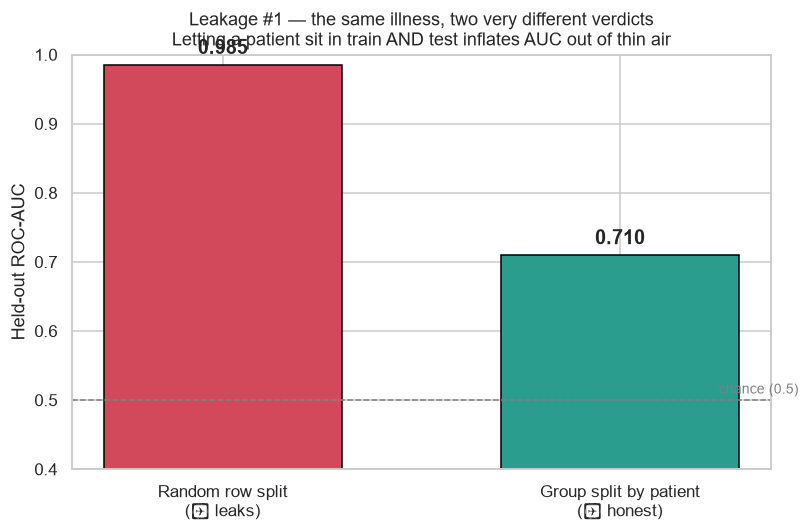

In [8]:
# 📊 Plot 1 — the centrepiece: inflated vs honest AUC
fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(["Random row split\n(❌ leaks)", "Group split by patient\n(✅ honest)"],
              [auc_random, auc_group],
              color=["#d1495b", "#2a9d8f"], edgecolor="black", width=0.6)
ax.axhline(0.5, ls="--", color="grey", lw=1)
ax.text(1.45, 0.505, "chance (0.5)", color="grey", ha="right", va="bottom", fontsize=9)
for b, v in zip(bars, [auc_random, auc_group]):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}",
            ha="center", va="bottom", fontsize=13, fontweight="bold")
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("Held-out ROC-AUC")
ax.set_title("Leakage #1 — the same illness, two very different verdicts\n"
             "Letting a patient sit in train AND test inflates AUC out of thin air",
             fontsize=12)
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** When you have **repeated measures per patient** (time series, multiple
> visits, multiple images per person), a random split lets the model *cheat by recognising the person*.
> **Always split by the patient key** (`GroupShuffleSplit`, `GroupKFold`, `StratifiedGroupKFold`). The
> honest AUC is lower — and it's the only one that would survive contact with a new patient.
>
> This is *exactly* why the patient-level table from Notebook 04 exists: with one row per stay, a normal
> stratified split is already patient-safe. But the moment you model raw time-series rows, group-split.

## ⚖️ Leakage #2 — scaling / imputing **before** the split

A subtler leak. Scalers (`StandardScaler`) and imputers (`SimpleImputer`) *learn* something from the
data — a mean, a standard deviation, a median. If you `fit` them on the **whole** dataset before
splitting, the training fold has secretly "seen" summary statistics of the test fold. That's information
from the future leaking backward.

The fix is beautifully simple: **put every learned step inside a `Pipeline`** and fit the pipeline on the
training fold only. The scaler's mean is then computed from train data alone.

On this tidy dataset the numeric gap is usually **small** — but the *principle* is absolute, and with
aggressive preprocessing (target encoding, feature selection by correlation with `y`, over-sampling) the
same mistake can be enormous. We'll switch to the patient table and a Logistic Regression (which actually
*needs* scaling) to see it.

In [9]:
# Patient-level modelling matrix (one row per stay -> a plain stratified split is patient-safe).
drop = ["icustayid", "morta_90", "died_in_hosp"]
Xp = patients.drop(columns=drop)
yp = patients["morta_90"].astype(int)

Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(
    Xp, yp, test_size=0.30, random_state=RANDOM_STATE, stratify=yp)

def logreg():
    return LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)

# ❌ WRONG: impute + scale using ALL rows (train AND test) before fitting the model.
imp_all = SimpleImputer(strategy="median").fit(Xp)          # <-- sees the test set
sc_all  = StandardScaler().fit(imp_all.transform(Xp))       # <-- sees the test set
Xtr_leak = sc_all.transform(imp_all.transform(Xp_tr))
Xte_leak = sc_all.transform(imp_all.transform(Xp_te))
m = logreg().fit(Xtr_leak, yp_tr)
auc_prep_leak = roc_auc_score(yp_te, m.predict_proba(Xte_leak)[:, 1])

# ✅ RIGHT: identical steps, but wrapped in a Pipeline fit on TRAIN ONLY.
pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                 ("sc",  StandardScaler()),
                 ("clf", logreg())])
auc_prep_ok = fit_eval(pipe, Xp_tr, yp_tr, Xp_te, yp_te)

print(f"AUC — preprocessing fit on ALL data (❌ leak) : {auc_prep_leak:.4f}")
print(f"AUC — preprocessing inside Pipeline (✅ safe) : {auc_prep_ok:.4f}")
print(f"Difference                                   : {auc_prep_leak - auc_prep_ok:+.4f}")
LEDGER.append(("Scale/impute\nbefore split", auc_prep_leak, auc_prep_ok))

AUC — preprocessing fit on ALL data (❌ leak) : 0.7801
AUC — preprocessing inside Pipeline (✅ safe) : 0.7798
Difference                                   : +0.0004


> 🧠 **Clinical takeaway.** The gap here is tiny — which is *dangerous*, because it makes the mistake
> easy to shrug off. The habit that saves you is mechanical: **anything that `.fit()`s must live inside a
> `Pipeline`, and the pipeline is fit inside cross-validation.** Never `fit_transform` on your full `X`.
> The leak becomes severe when preprocessing is powerful — e.g. selecting the top-20 features by their
> correlation with the outcome across *all* rows, or SMOTE-oversampling before the split (see below).

## 🎯 Leakage #3 — a **target-leaking feature** (AUC → 1.0)

The most embarrassing leak, and the easiest to catch once you're suspicious: **a feature that is really
the answer in disguise.** We'll look at two flavours.

**(a) A partial proxy already in our table — `died_in_hosp`.** This flags death *during this hospital
admission*. Because almost everyone who dies in hospital also dies within 90 days, it's a strong hint —
but it only catches **about half** of the 90-day deaths (many die *after* discharge), so it inflates the AUC
without pinning it to 1.0.

**(b) A near-perfect proxy — a discharge-time variable.** Imagine someone adds a
`discharge_disposition == "expired"` flag. That is recorded **at discharge**, i.e. *after* the outcome is
known — it's essentially the label wearing a disguise. Handing it to the model is like predicting exam
results *after* peeking at the grades. Watch the AUC pin itself to the top-left corner.

In [10]:
# The smoking gun: how well does each "feature" already agree with the target?
print("died_in_hosp: P(morta_90=1 | died_in_hosp=1) =",
      f"{patients.loc[patients['died_in_hosp']==1,'morta_90'].mean():.1%}  "
      f"but only catches {patients.loc[patients['morta_90']==1,'died_in_hosp'].mean():.0%} of deaths")

# ❌ (a) include died_in_hosp — a PARTIAL outcome proxy.
Xleak = patients.drop(columns=["icustayid", "morta_90"])   # keeps died_in_hosp!
Xlk_tr, Xlk_te = Xleak.loc[Xp_tr.index], Xleak.loc[Xp_te.index]
auc_partial_leak = fit_eval(rf_pipe(), Xlk_tr, yp_tr, Xlk_te, yp_te)

# ❌ (b) a NEAR-PERFECT proxy: a discharge-time "expired" flag (the label in disguise, ~2% mis-coded).
rng = np.random.default_rng(0)
discharge_expired = patients["morta_90"].values ^ (rng.random(len(patients)) < 0.02).astype(int)
Xproxy = Xp.assign(discharge_expired=discharge_expired)     # Xp has NO died_in_hosp
Xpx_tr, Xpx_te = Xproxy.loc[Xp_tr.index], Xproxy.loc[Xp_te.index]
auc_target_leak = fit_eval(rf_pipe(), Xpx_tr, yp_tr, Xpx_te, yp_te)

# ✅ the honest model (no outcome proxies) — our AUC from Leak #2's pipeline.
auc_honest = auc_prep_ok

print(f"\nAUC honest (no proxies, ✅)            : {auc_honest:.3f}")
print(f"AUC + died_in_hosp (partial proxy, ❌) : {auc_partial_leak:.3f}   ← inflated")
print(f"AUC + discharge_expired (❌❌)          : {auc_target_leak:.3f}   ← 'perfect' 🚩")
LEDGER.append(("Target-leak feature\n(discharge disposition)", auc_target_leak, auc_honest))

died_in_hosp: P(morta_90=1 | died_in_hosp=1) = 97.3%  but only catches 47% of deaths



AUC honest (no proxies, ✅)            : 0.780
AUC + died_in_hosp (partial proxy, ❌) : 0.858   ← inflated
AUC + discharge_expired (❌❌)          : 0.993   ← 'perfect' 🚩


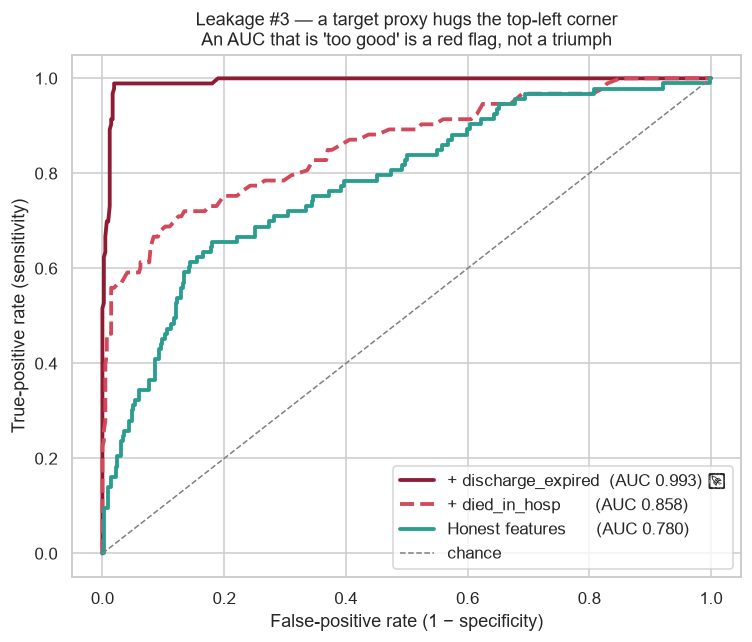

In [11]:
# 📊 Plot 2 — ROC curves: honest vs partial-proxy vs near-perfect proxy
fig, ax = plt.subplots(figsize=(7, 6))

m_proxy = rf_pipe().fit(Xpx_tr, yp_tr)
fpr_p, tpr_p, _ = roc_curve(yp_te, m_proxy.predict_proba(Xpx_te)[:, 1])
m_part = rf_pipe().fit(Xlk_tr, yp_tr)
fpr_d, tpr_d, _ = roc_curve(yp_te, m_part.predict_proba(Xlk_te)[:, 1])
m_ok = pipe.fit(Xp_tr, yp_tr)
fpr_o, tpr_o, _ = roc_curve(yp_te, m_ok.predict_proba(Xp_te)[:, 1])

ax.plot(fpr_p, tpr_p, color="#8e1c33", lw=2.5,
        label=f"+ discharge_expired  (AUC {auc_target_leak:.3f}) 🚩")
ax.plot(fpr_d, tpr_d, color="#d1495b", lw=2.5, ls="--",
        label=f"+ died_in_hosp       (AUC {auc_partial_leak:.3f})")
ax.plot(fpr_o, tpr_o, color="#2a9d8f", lw=2.5,
        label=f"Honest features      (AUC {auc_honest:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="grey", lw=1, label="chance")
ax.set_xlabel("False-positive rate (1 − specificity)")
ax.set_ylabel("True-positive rate (sensitivity)")
ax.set_title("Leakage #3 — a target proxy hugs the top-left corner\n"
             "An AUC that is 'too good' is a red flag, not a triumph", fontsize=12)
ax.legend(loc="lower right", frameon=True)
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** An AUC near **1.0 on a genuinely hard clinical problem is almost always a
> leak, not a breakthrough.** Interrogate any feature that is *too* predictive. Classic culprits in EHR
> data: **discharge disposition**, "comfort-care"/DNR orders, the death timestamp, ICD codes assigned at
> discharge, a lab that is only ordered *because* the patient is dying, or any variable recorded **after**
> the moment you claim to be predicting. Note how even a *partial* proxy (`died_in_hosp`) still inflated
> the score. Ask of every feature: *"would this value truly be available, for a new patient, at prediction
> time?"* If not, drop it.

## 🎛️ Leakage #4 — tuning on the test set

You try 12 settings of a hyperparameter, look at the **test** AUC for each, and report the best one. That
number is optimistic: you've let the test set *choose* the model, so it's no longer an unbiased estimate.
With enough knobs you can "tune" your way to a good score on **pure noise**.

The honest recipe: pick hyperparameters with **cross-validation on the training data only**, then touch
the test set **exactly once**, at the very end.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from itertools import product

# A realistic little "grid search": ~135 hyper-parameter combinations.
grid = list(product([2, 3, 4, 5, 6, 8, 10, 15, None],   # max_depth
                    [1, 2, 5, 10, 20],                   # min_samples_leaf
                    [None, "sqrt", 0.5]))                # max_features
test_aucs, cv_aucs = [], []

for d, leaf, mf in grid:
    tree = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("tree", DecisionTreeClassifier(max_depth=d, min_samples_leaf=leaf,
                                                     max_features=mf, class_weight="balanced",
                                                     random_state=RANDOM_STATE))])
    test_aucs.append(fit_eval(tree, Xp_tr, yp_tr, Xp_te, yp_te))   # peeking at TEST
    cv = cross_val_score(tree, Xp_tr, yp_tr, cv=StratifiedKFold(5, shuffle=True,
                         random_state=RANDOM_STATE), scoring="roc_auc")
    cv_aucs.append(cv.mean())                                      # honest: CV on TRAIN

test_aucs, cv_aucs = np.array(test_aucs), np.array(cv_aucs)

# ❌ pick the config with the best TEST auc, and report that test auc
best_by_test = int(test_aucs.argmax())
auc_tuned_on_test = test_aucs[best_by_test]
# ✅ pick the config with the best CV auc; report its (single, untouched) test auc
best_by_cv = int(cv_aucs.argmax())
auc_tuned_on_cv = test_aucs[best_by_cv]

print(f"Tried {len(grid)} configs.")
print(f"Best by peeking at TEST : {grid[best_by_test]}  -> reported AUC {auc_tuned_on_test:.3f}  (❌ optimistic)")
print(f"Best by CV on TRAIN     : {grid[best_by_cv]}  -> honest test AUC {auc_tuned_on_cv:.3f}  (✅)")
print(f"Optimism from peeking   : +{auc_tuned_on_test - auc_tuned_on_cv:.3f} AUC")
LEDGER.append(("Tuned on the\ntest set", auc_tuned_on_test, auc_tuned_on_cv))

Tried 135 configs.
Best by peeking at TEST : (5, 20, 'sqrt')  -> reported AUC 0.730  (❌ optimistic)
Best by CV on TRAIN     : (4, 20, 'sqrt')  -> honest test AUC 0.673  (✅)
Optimism from peeking   : +0.057 AUC


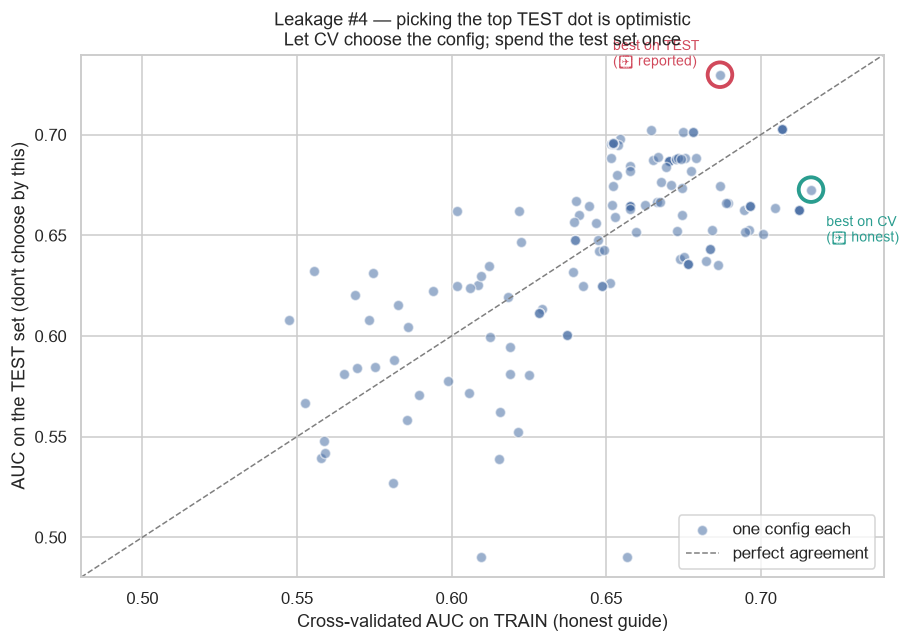

In [13]:
# 📊 Plot 3 — every dot is one hyper-parameter config: does CV agree with the test set?
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(cv_aucs, test_aucs, s=45, alpha=0.55, color="#4a6fa5", edgecolor="white",
           label="one config each")
lims = [min(cv_aucs.min(), test_aucs.min())-0.01, max(cv_aucs.max(), test_aucs.max())+0.01]
ax.plot(lims, lims, ls="--", color="grey", lw=1, label="perfect agreement")
ax.scatter([cv_aucs[best_by_test]], [auc_tuned_on_test], s=260, facecolors="none",
           edgecolors="#d1495b", linewidths=2.5, zorder=5)
ax.annotate("best on TEST\n(❌ reported)", (cv_aucs[best_by_test], auc_tuned_on_test),
            textcoords="offset points", xytext=(-70, 6), color="#d1495b", fontsize=9)
ax.scatter([cv_aucs[best_by_cv]], [auc_tuned_on_cv], s=260, facecolors="none",
           edgecolors="#2a9d8f", linewidths=2.5, zorder=5)
ax.annotate("best on CV\n(✅ honest)", (cv_aucs[best_by_cv], auc_tuned_on_cv),
            textcoords="offset points", xytext=(10, -34), color="#2a9d8f", fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Cross-validated AUC on TRAIN (honest guide)")
ax.set_ylabel("AUC on the TEST set (don't choose by this)")
ax.set_title("Leakage #4 — picking the top TEST dot is optimistic\n"
             "Let CV choose the config; spend the test set once", fontsize=12)
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** Your test set is a **one-shot** measurement of generalisation — spend it
> once. Every decision you make by looking at the test score (features, thresholds, hyperparameters,
> "let me just try one more model") quietly biases the final number upward. Use CV (or a separate
> validation split) for *all* choices; report the held-out test score untouched. For repeated selection,
> **nested CV** is the gold standard.

## 📉 The accuracy trap — and imbalance done wrong

Only **≈18 %** of these patients died, so a lazy model that predicts **"everybody survives"** is right
82 % of the time. High accuracy, **zero** clinical value: it never once flags a death.

In [14]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(Xp_tr, yp_tr)
dpred = dummy.predict(Xp_te)
print(f"'Everybody survives' accuracy : {accuracy_score(yp_te, dpred):.1%}   😮 looks great")
print(f"   …but recall for death      : {recall_score(yp_te, dpred):.1%}   ← catches NOBODY")
print(f"   …and ROC-AUC               : 0.500   ← no discrimination at all\n")

real = pipe.fit(Xp_tr, yp_tr)
rp = real.predict(Xp_te)
print(f"Real model accuracy           : {accuracy_score(yp_te, rp):.1%}")
print(f"Real model recall for death   : {recall_score(yp_te, rp):.1%}")
print(f"Real model ROC-AUC            : {roc_auc_score(yp_te, real.predict_proba(Xp_te)[:,1]):.3f}")

'Everybody survives' accuracy : 81.7%   😮 looks great
   …but recall for death      : 0.0%   ← catches NOBODY
   …and ROC-AUC               : 0.500   ← no discrimination at all

Real model accuracy           : 76.6%
Real model recall for death   : 65.6%
Real model ROC-AUC            : 0.780


> ⚠️ **SMOTE / oversampling done wrong = leakage.** Balancing classes (SMOTE, random oversampling) is
> tempting, but if you resample **before** splitting, synthetic points derived from test patients end up in
> training — another leak that inflates your score. Always resample **inside** the CV fold, on training data
> only (e.g. with `imblearn`'s `Pipeline`). Under imbalance, prefer **ROC-AUC, PR-AUC/average precision,
> recall at a fixed alarm budget, and calibration** over raw accuracy (see Notebook 06).

## 🌍 Temporal & external validation — the test that matters at the bedside

Even a perfectly leak-free random split answers a gentle question: *"can the model predict patients drawn
from the **same** pool?"* Deployment asks a harder one: *"does it still work on patients from a **different
time or a different hospital**?"* Distributions shift — case mix, protocols, lab assays, documentation —
and performance usually **drops**. Better to discover that in validation than in production.

We can't ship you a second hospital, so we **simulate a distribution shift**: train on one subgroup and
test on a *different* one. Here: **train on younger patients, test on older patients.** Compare that to an
in-distribution split of the same size.

In [15]:
age_med = patients["age"].median()
young = patients[patients["age"] <  age_med]
old   = patients[patients["age"] >= age_med]

def Xy(frame):
    return frame.drop(columns=drop), frame["morta_90"].astype(int)

# --- External-style: train on YOUNG, test on OLD (a deliberate case-mix shift) ---
Xy_tr, yy_tr = Xy(young)
Xo_te, yo_te = Xy(old)
auc_external = fit_eval(rf_pipe(), Xy_tr, yy_tr, Xo_te, yo_te)

# --- In-distribution baseline: random split of the YOUNG cohort (same 'home' population) ---
Xy_a, Xy_b, yy_a, yy_b = train_test_split(Xy_tr, yy_tr, test_size=0.30,
                                          random_state=RANDOM_STATE, stratify=yy_tr)
auc_internal = fit_eval(rf_pipe(), Xy_a, yy_a, Xy_b, yy_b)

print(f"AUC — tested on the SAME (young) population   : {auc_internal:.3f}")
print(f"AUC — transferred to a DIFFERENT (old) cohort : {auc_external:.3f}")
print(f"Generalisation gap                            : {auc_internal - auc_external:+.3f}")
LEDGER.append(("Same population\nvs shifted cohort", auc_internal, auc_external))

AUC — tested on the SAME (young) population   : 0.820
AUC — transferred to a DIFFERENT (old) cohort : 0.735
Generalisation gap                            : +0.085


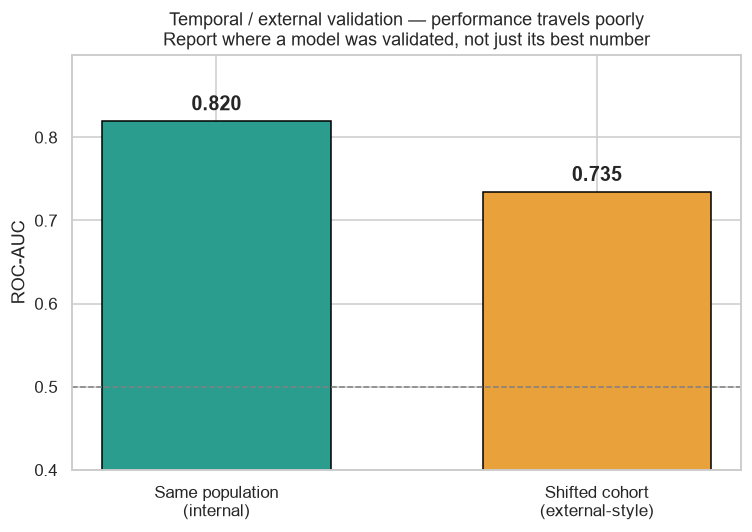

In [16]:
# 📊 Plot 4 — internal vs shifted-cohort performance
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(["Same population\n(internal)", "Shifted cohort\n(external-style)"],
              [auc_internal, auc_external],
              color=["#2a9d8f", "#e9a23b"], edgecolor="black", width=0.6)
for b, v in zip(bars, [auc_internal, auc_external]):
    ax.text(b.get_x()+b.get_width()/2, v+0.008, f"{v:.3f}",
            ha="center", va="bottom", fontsize=13, fontweight="bold")
ax.axhline(0.5, ls="--", color="grey", lw=1)
ax.set_ylim(0.4, max(auc_internal, auc_external)+0.08)
ax.set_ylabel("ROC-AUC")
ax.set_title("Temporal / external validation — performance travels poorly\n"
             "Report where a model was validated, not just its best number", fontsize=12)
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** A single-centre AUC is a *promise*, not a *proof*. Before trusting a model
> at the bedside, ask for **temporal validation** (train on earlier admissions, test on later ones) and
> ideally **external validation** at another site. Expect the number to fall; a model whose performance
> *survives* the shift is the one worth deploying. This is why regulators and good journals now demand it.

## 🧾 The wall of shame — every inflated number, side by side
Every leak we built inflated the headline metric. Here they all are: the seductive **BEFORE** vs the honest **AFTER**.

,mistake,inflated,honest,inflation
0,Random row split\n(patient overlap),0.985,0.710,0.275
1,Scale/impute\nbefore split,0.780,0.780,0.000
2,Target-leak feature\n(discharge disposition),0.993,0.780,0.213
3,Tuned on the\ntest set,0.730,0.673,0.057
4,Same population\nvs shifted cohort,0.820,0.735,0.085


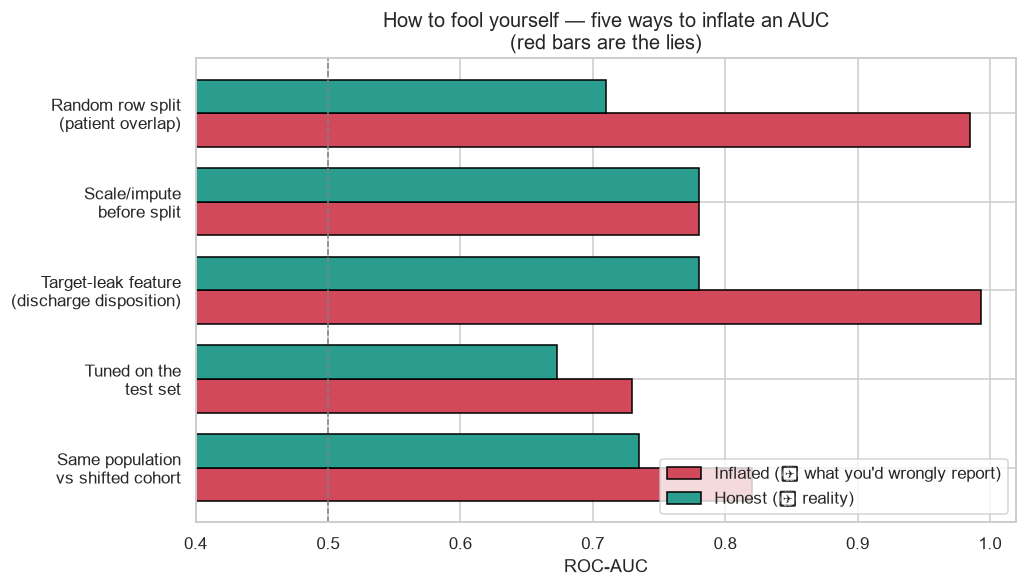

In [17]:
# Round FIRST, then subtract, so the printed inflation is exactly the printed difference.
ledger = pd.DataFrame(LEDGER, columns=["mistake", "inflated", "honest"]).round(3)
ledger["inflation"] = (ledger["inflated"] - ledger["honest"]).round(3)
display(ledger)

# 📊 Plot 5 — grouped bars: inflated vs honest for every mistake
y = np.arange(len(ledger)); h = 0.38
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.barh(y+h/2, ledger["inflated"], height=h, color="#d1495b",
        edgecolor="black", label="Inflated (❌ what you'd wrongly report)")
ax.barh(y-h/2, ledger["honest"],   height=h, color="#2a9d8f",
        edgecolor="black", label="Honest (✅ reality)")
ax.axvline(0.5, ls="--", color="grey", lw=1)
ax.set_yticks(y); ax.set_yticklabels(ledger["mistake"])
ax.set_xlim(0.4, 1.02); ax.set_xlabel("ROC-AUC")
ax.invert_yaxis()
ax.set_title("How to fool yourself — five ways to inflate an AUC\n(red bars are the lies)", fontsize=13)
ax.legend(loc="lower right", frameon=True)
plt.tight_layout(); plt.show()

## ✏️ Your turn

Time to hunt leaks yourself. Each exercise has a collapsible solution — try it before peeking.

### Exercise 1 — Spot the leak in this snippet

Below is a snippet a colleague proudly shows you: *"AUC 0.94 predicting 90-day mortality!"* **There are
(at least) two leaks.** Read it, name them, then fix them in the code cell.

```python
# colleague's code (do NOT run — it's the buggy version)
X = patients.drop(columns=["icustayid", "morta_90"])
X = StandardScaler().fit_transform(X)                      # (a)
X_tr, X_te, y_tr, y_te = train_test_split(X, patients["morta_90"], test_size=0.3)
model = RandomForestClassifier().fit(X_tr, y_tr)
print(roc_auc_score(y_te, model.predict_proba(X_te)[:, 1]))
```

Write the two leaks in a comment, then produce an honest AUC.

In [18]:
# TODO: name the two leaks in comments, then compute an HONEST AUC.
# Leak 1: ______________________________________________
# Leak 2: ______________________________________________

# your fixed pipeline here...


<details><summary>💡 Show solution</summary>

**Leak 1 — target leakage:** dropping only `morta_90` leaves **`died_in_hosp`** in `X`, which is an
outcome proxy (≈ the target). It must be dropped too.

**Leak 2 — preprocessing before the split:** `StandardScaler().fit_transform(X)` is fit on the *whole*
dataset (train **and** test). The scaler must live inside a `Pipeline` fit on the training fold only.

```python
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = patients.drop(columns=["icustayid", "morta_90", "died_in_hosp"])   # fix leak 1
y = patients["morta_90"].astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                 ("sc",  StandardScaler()),                            # fix leak 2
                 ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                            random_state=RANDOM_STATE))])
pipe.fit(X_tr, y_tr)
print(f"Honest AUC: {roc_auc_score(y_te, pipe.predict_proba(X_te)[:,1]):.3f}")
```
The honest AUC lands near ≈0.78–0.80 — believable, and far below the leaky 0.94.
</details>

### Exercise 2 — Prove the patient-split point with cross-validation

In Leak #1 we used a single split. Show it holds under cross-validation on the raw `ts` file: compare
`StratifiedKFold` (❌ ignores patients) with `GroupKFold` grouped by `icustayid` (✅). Report the mean AUC
of each — the grouped one should be **lower and honest**.

In [19]:
from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_score

# TODO: fill in the two cross_val_score calls on (Xr, yr) using rf_pipe().
# Hint: GroupKFold needs groups=... ; StratifiedKFold does not.

# naive_scores = cross_val_score(...)
# group_scores = cross_val_score(...)
# print naive vs grouped mean AUC


<details><summary>💡 Show solution</summary>

```python
from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_score

# ❌ ignores patients — rows of one stay scatter across folds
naive = cross_val_score(rf_pipe(), Xr, yr,
                        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                        scoring="roc_auc")

# ✅ every patient's rows stay together in one fold
grouped = cross_val_score(rf_pipe(), Xr, yr, groups=groups,
                          cv=GroupKFold(5), scoring="roc_auc")

print(f"StratifiedKFold (❌ leaky) mean AUC : {naive.mean():.3f} ± {naive.std():.3f}")
print(f"GroupKFold      (✅ honest) mean AUC : {grouped.mean():.3f} ± {grouped.std():.3f}")
```
The grouped mean is markedly lower — the same lesson as the single split, now robust to fold choice.
</details>

### Exercise 3 (stretch) — How much can you inflate with pure noise?

Add a column of **random numbers** to the patient table and *tune on the test set* over 30 of them,
reporting the best test AUC. Even random features let you nudge the reported score up — a vivid reminder
that test-set peeking rewards luck.

In [20]:
# TODO: add 30 random feature-sets (or 30 random seeds) and keep the best TEST auc.
# Compare it to a single honest evaluation. What's the "free" inflation from peeking?


<details><summary>💡 Show solution</summary>

```python
rng = np.random.default_rng(0)
best = 0
for _ in range(30):
    Xn = Xp.assign(noise=rng.normal(size=len(Xp)))          # a useless random feature
    a, b, ya, yb = train_test_split(Xn, yp, test_size=0.30,
                                    random_state=int(rng.integers(1e6)), stratify=yp)
    best = max(best, fit_eval(rf_pipe(), a, ya, b, yb))     # keep the luckiest split/feature
print(f"Best-of-30 (❌ peeking) AUC : {best:.3f}")
print(f"Single honest AUC          : {auc_honest:.3f}")
print(f"'Free' inflation from luck : {best - auc_honest:+.3f}")
```
Trying many things and reporting the best is a leak too — the multiple-comparisons problem in disguise.
</details>

## ✅ Recap

- **Split by the patient key.** Repeated measures (time series, revisits, multiple images) leak through a
  random split. Use `GroupShuffleSplit` / `GroupKFold`. This was our biggest inflation.
- **Fit preprocessing inside the training fold.** Scalers and imputers learn from data — wrap them in a
  `Pipeline`; never `fit_transform` on your full `X`.
- **Audit every feature for target leakage.** Anything recorded at/after the outcome (or a proxy of it,
  like `died_in_hosp`) gives a fake ≈1.0 AUC. If it's *too* good, it's a leak.
- **Spend the test set once.** Choose features, thresholds and hyperparameters with CV on train; report the
  held-out score untouched. Tuning on test inflates.
- **Accuracy lies under imbalance.** "Everybody survives" scores 82 % and helps nobody. Use AUC, PR-AUC,
  recall-at-budget and calibration. Resample *inside* the fold.
- **Validate where it counts.** Single-centre AUC is a promise; **temporal** and **external** validation
  are the proof. Expect — and report — the drop.

> 🧠 **The one-line habit:** *"Would this information truly be available, for a brand-new patient, at the
> moment I make the prediction?"* Ask it of every feature, every split, every preprocessing step.

## ➡️ Next

You now know how to keep yourself honest. In **Notebook 09 — Optimizing your model**, we put it to
work: measure whether cleaning actually helps, run a proper cross-validated hyperparameter search, and
compare model families on an honest leaderboard.

*Well done — spotting leakage is one of the most valuable skills a clinical data scientist can have.* 🎉

<!-- nav-footer -->
---

### ➡️ Next up — Notebook 09: Optimizing your model

<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/09_model_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Notebook 09 in Colab" height="32"/></a>

👉 **[Continue to Notebook 09 — Optimizing your model](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/09_model_optimization.ipynb)**

[⬅ Back to Notebook 07](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/07_explainable_ai.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · [📁 The course on GitHub](https://github.com/lorenzkap/ML2026)